<a href="https://colab.research.google.com/github/carlosprr29/ai-progetto-spagnoli/blob/main/notebooks/01_1_Exploratory_Data_Analysis_WELFake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =================================================================
# PHASE: Exploratory Data Analysis (EDA) - WELFake Dataset
# =================================================================

# 1. INSTALLATION AND LOADING OF LIBRARIES
# -----------------------------------------------------------------
print(" Installing and loading libraries...")
!pip install -q datasets pandas matplotlib seaborn wordcloud

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datasets import load_dataset
import warnings

warnings.filterwarnings('ignore') # To clean up the output of unnecessary warnings

In [ ]:
# 2. LOADING THE DATASET FROM HUGGING FACE
# -----------------------------------------------------------------
print(" Loading WELFake dataset (this may take a minute)...")
dataset_raw = load_dataset("davanstrien/WELFake")
df = pd.DataFrame(dataset_raw['train'])

# Initial cleaning: remove rows with nulls and duplicates
df = df.dropna(subset=['title', 'text', 'label'])
df = df.drop_duplicates()
print(f" Dataset successfully loaded with {len(df)} rows.")

In [ ]:
# 3. CLASS BALANCE ANALYSIS (Bar chart)
# -----------------------------------------------------------------
print("\n Generating class balance chart...")
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('News Distribution (0: Real, 1: Fake)')
plt.xticks([0, 1], ['Real', 'Fake'])
plt.show()

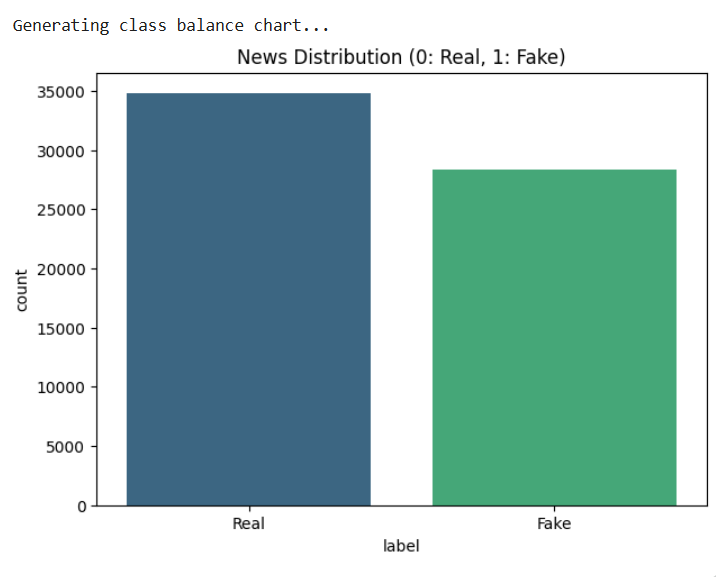

In [ ]:
# 4. CONTENT EXPLORATION (Sampling)
# -----------------------------------------------------------------
print("\n Displaying 10 random news items from the dataset:")
display(df[['title', 'label']].sample(50))

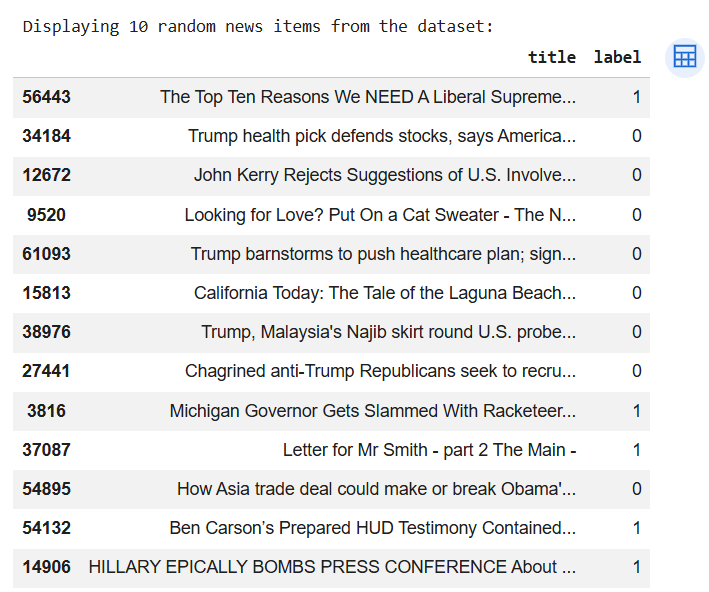

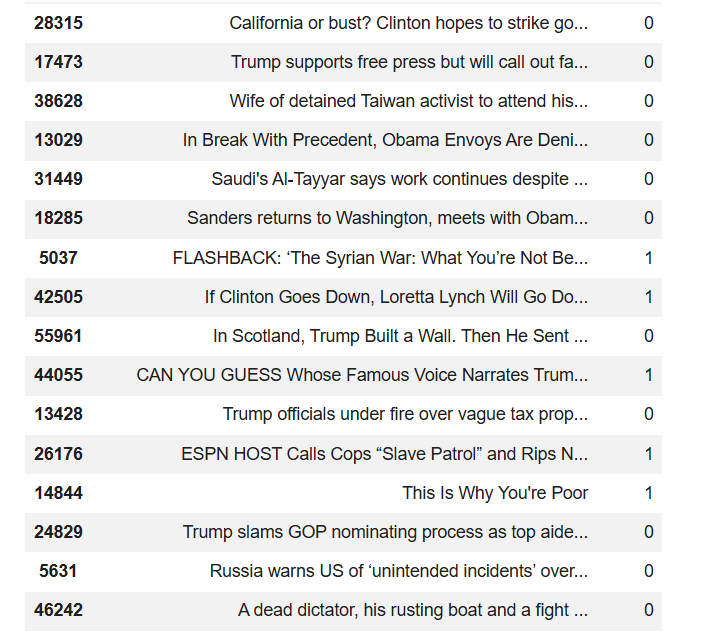

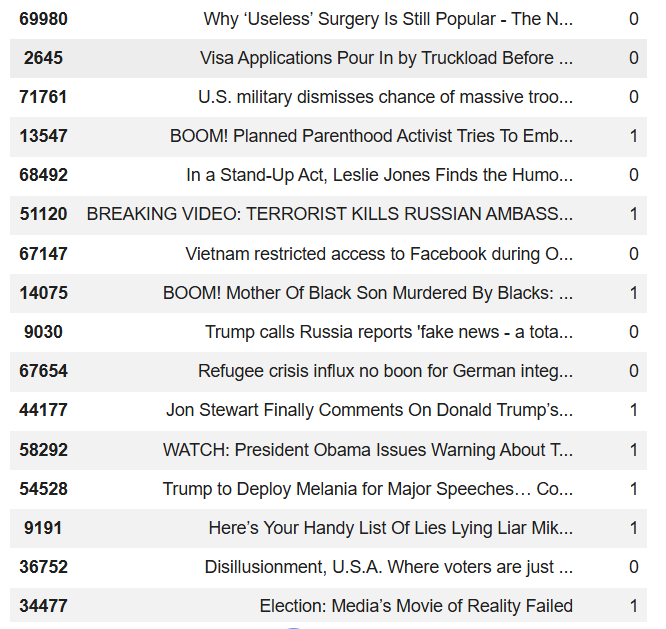

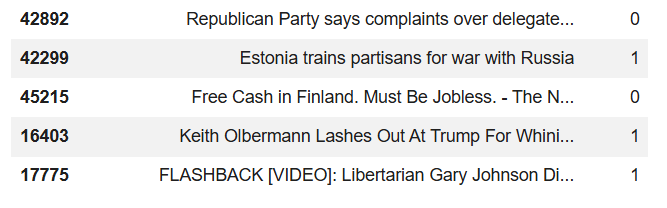

Analyzing a random sample of the dataset (50 records) revealed that genuine news stories (label 0) exhibit a very conservative grammatical structure and typically include the media outlet's byline ( NYT or Breitbart).

Conversely, fake news stories (label 1) overuse sensationalist terms like 'BOOM!' or 'WATCH' and informative tags like 'VIDEO'. This structural difference explains why the BERT model achieves training metrics close to 100%, but fails when faced with current news stories where journalistic style has evolved or lacks these obvious markers.

In [ ]:
# 5. TITLE LENGTH ANALYSIS
# ----------------------------------------------------------------
print("\n Analysing title length...")
df['title_len'] = df['title'].astype(str).apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='title_len', hue='label', kde=True, bins=100, palette='magma')
plt.title('Comparison of Title Length: Real vs Fake')
plt.xlim(0, 200) # We focus our attention on the most common range.
plt.xlabel('Number of characters')
plt.show()

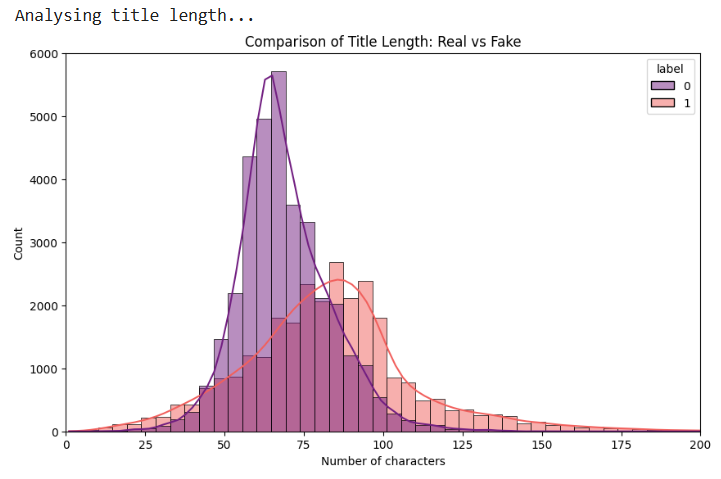

As observed in the headline length analysis, there is a marked structural difference between the two classes. While real news stories have a normalized and compact length (peaking at 65 characters), fake news stories tend to be significantly longer.

This finding suggests a design bias in the dataset: the BERT model may be using text length as a statistical predictor instead of performing deep semantic understanding, which would explain the performance degradation when dealing with modern real news stories with more flexible headline structures.

In [ ]:
# 6. WORD CLOUD GENERATION (Term visualisation)
# -----------------------------------------------------------------
print("\n Generating word clouds (WordClouds)...")
def generate_cloud(news_class, graph_title, colour_map):
    text = " ".join(df[df['label'] == news_class]['title'].astype(str))
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap=colour_map).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(graph_title, fontsize=16)
    plt.axis('off')
    plt.show()

# Cloud for Real news (label 0)
generate_cloud(0, "Most common words in REAL headlines", "ocean")

# Cloud for Fake news (label 1)
generate_cloud(1, "Most common words in FAKE headlines", "Reds")

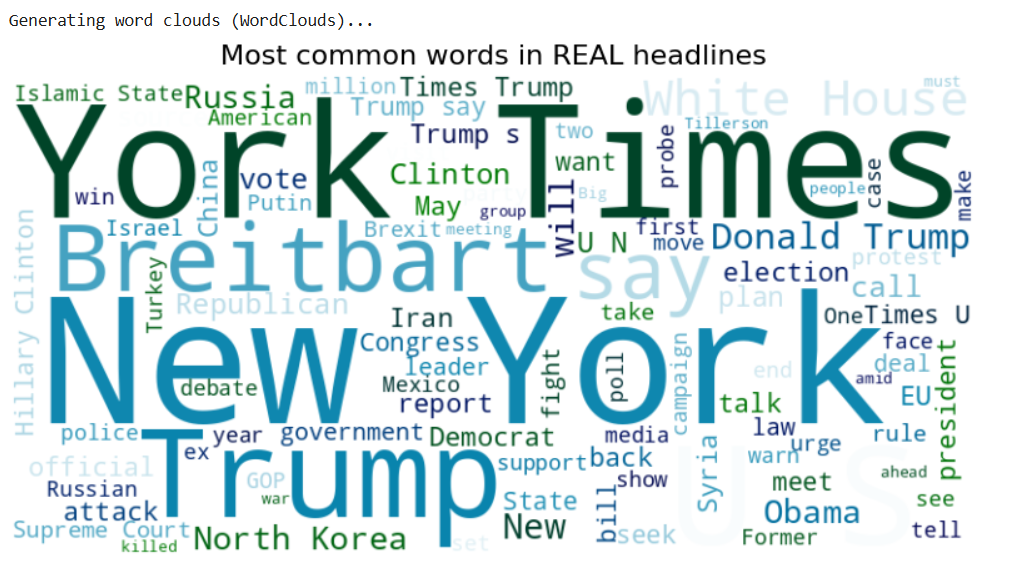

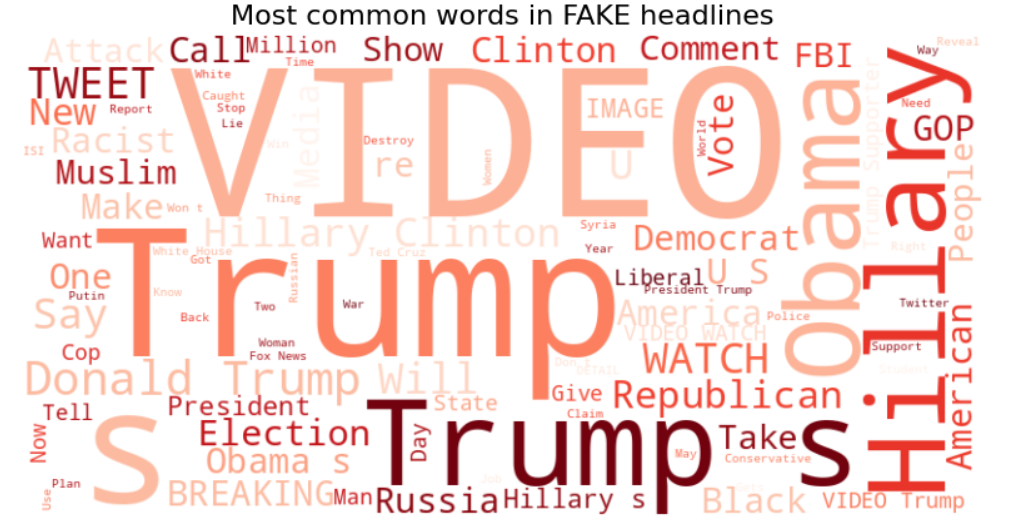

Word cloud analysis reveals a critical lexical divergence between the two classes. While real news is strongly linked to specific newspaper names (NYT), fake news is characterized by the use of sensationalist format tags like 'VIDEO' or 'WATCH'.

This uneven distribution of terms generates a vocabulary bias: the BERT-based model, having limited semantic capacity for this volume of data, opts to classify based on the presence of these high-impact 'tokens'. This explains why the system could fails to classify modern real news stories that employ multimedia formats or satirical news stories that perfectly mimic the institutional lexicon of real sources but with implausible content.

In [ ]:
# 7. SPECIFIC KEYWORD SEARCH ENGINE
# -----------------------------------------------------------------
def analyse_term(term):
    filter = df[df['title'].str.contains(term, case=False, na=False)]
    if not filter.empty:
        count = filter['label'].value_counts(normalize=True) * 100
        print(f"\n The term '{term}' appears in {len(filter)} titles.")
        print(f"   Distribution: {count.to_dict()}")
    else:
        print(f"\n The term '{term}' was not found.")

analyse_term("Trump")
analyse_term("VIDEO")
analyse_term("Breaking")
analyse_term("Nasa")

 The term 'Trump' appears in 17433 titles.
   Distribution: {1: 51.64343486491138, 0: 48.35656513508862}

 The term 'VIDEO' appears in 6938 titles.
   Distribution: {1: 96.98760449697319, 0: 3.012395503026809}

 The term 'Breaking' appears in 841 titles.
   Distribution: {1: 96.6706302021403, 0: 3.329369797859691}

 The term 'Nasa' appears in 38 titles.
   Distribution: {1: 65.78947368421053, 0: 34.21052631578947}

#Conclusion
Our keyword inspection reveals why the model struggles with generalization. Terms like 'VIDEO' and 'Breaking' are present in Fake News 97% of the time. This creates a "heuristic shortcut" where BERT learns to associate specific words with falsehood, rather than analyzing the semantic meaning. Conversely, balanced terms like 'Trump' (50/50 distribution) force the model to look for deeper context.